In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

In [2]:
# helper methods -------------------------------------------

def df_to_accuracy(frame):
    frame['correct'] = frame['true_label'] == frame['predicted_label']
    stats_df = frame.groupby('true_label')['correct'].mean()

    stats_df.loc['total'] = frame['correct'].mean()
    # print(stats_df)
    return stats_df

### data cleanup

go from predictions of individual records -> per-class, per-layer accuracy (for now) statistics

In [3]:
# load our predictions for manners of articulation
df_stats = pd.DataFrame(columns=['encoder', 'layer', 'class', 'accuracy'])

# TODO: CHANGE THESE INDICES BACK TO 12, 12, 32 respectively
for i in range(11):
    # print("predictions/whisperMOA/layer" + str(i) + ".csv")
    layer_df = df_to_accuracy(pd.read_csv("predictions/whisperMOA/layer" + str(i) + ".csv"))

    for class_name, accuracy in layer_df.items():
        df_stats.loc[len(df_stats)] = ['whisper', i, class_name, accuracy]  

for i in range(11):
    layer_df = df_to_accuracy(pd.read_csv("predictions/wav2vecMOA/layer" + str(i) + ".csv"))

    for class_name, accuracy in layer_df.items():
        df_stats.loc[len(df_stats)] = ['wav2vec', i, class_name, accuracy]  

for i in range(31):
    layer_df = df_to_accuracy(pd.read_csv("predictions/voxtralMOA/layer" + str(i) + ".csv"))

    for class_name, accuracy in layer_df.items():
        df_stats.loc[len(df_stats)] = ['voxtral', i, class_name, accuracy]    

In [12]:
# normalizes
# ------------------------------------------------------- for each encoder,       get the max layer 
df_stats["layerNorm"] = df_stats["layer"] / df_stats.groupby("encoder")["layer"].transform("max")

     encoder  layer        class  accuracy  layerNorm
0    whisper      0    affricate  0.000000        0.0
1    whisper      0  approximant  0.000000        0.0
2    whisper      0    fricative  0.929943        0.0
3    whisper      0        nasal  0.000000        0.0
4    whisper      0         stop  0.000000        0.0
..       ...    ...          ...       ...        ...
366  voxtral     30    fricative  0.945361        1.0
367  voxtral     30        nasal  0.905808        1.0
368  voxtral     30         stop  0.883472        1.0
369  voxtral     30        vowel  0.964917        1.0
370  voxtral     30        total  0.926935        1.0

[371 rows x 5 columns]


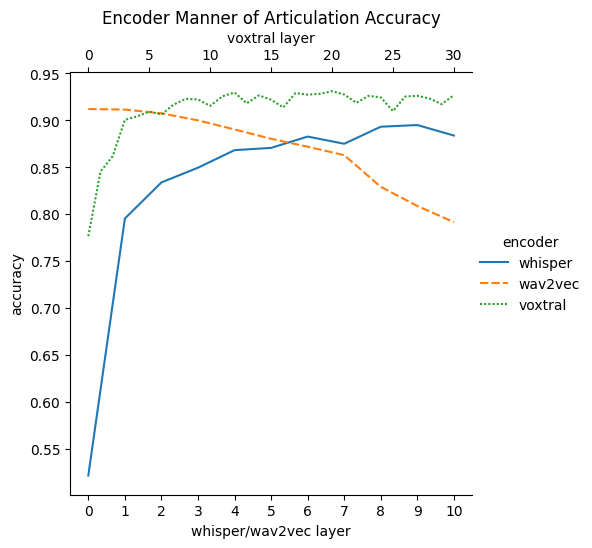

In [28]:
print(df_stats)

fig = sns.relplot(
    data=df_stats[df_stats["class"] == "total"], kind="line",
    x="layerNorm", y="accuracy",
    hue="encoder", style="encoder",
    # height=3, aspect=1.6
)

ax = fig.ax

ax.set_xticks([i/10 for i in range(11)])
ax.set_xticklabels(i for i in range(11))
ax.set_xlabel("whisper/wav2vec layer")

top_ax = ax.secondary_xaxis("top", functions=(lambda x: x * 30, lambda x: x / 30))
top_ax.set_xticks(range(0, 31, 5))
top_ax.set_xlabel("voxtral layer")

ax.set_title("Encoder Manner of Articulation Accuracy")
plt.savefig("figures/layerwiseMoaAccuracy.png", bbox_inches="tight")